In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr; import time as time
import matplotlib.colors as colors

folder_path = '/mnt/lustre/koa/koastore/torri_group/air_directory/figures' 
import os; os.makedirs(folder_path, exist_ok=True)

data=xr.open_dataset('/mnt/lustre/koa/koastore/torri_group/air_directory/cm1r20.3/run/cm1out_test7tundra-7_062217.nc')

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/'
whereCL=xr.open_dataset(dir+'tracking_algorithms/whereCL_4_0622.nc')
def get_3dtime_data(data,varname,tlev):
    cloud_var=data[varname].isel(time=tlev).values
    return cloud_var
def cd2d(f,dx,dy): #size not compatible, cant calculate adjacent gradient
    ddx = (
            f[:,:, 1:  ]
            -
            f[:,:, 0:-1]
        ) / (
        2 * dx
    )
    
    ddy = (
        f[:,1:, :]
        -
        f[:,0:-1, :]
    ) / (
        2 * dy
    )
    
    return ddx, ddy
def get_time(t):
    init_day,init_hour,init_min=0,0,0
    times=data['time'].values/(1e9 * 60); time_inc=times.astype(int)[1]-times.astype(int)[0]
    current_min=init_hour*60+init_min+time_inc*t;
    
    days = init_day + (current_min // (24 * 60))
    
    remain_min = (init_min+time_inc*t) % (24 * 60); 
    hours = (init_hour + (remain_min // 60)) % 24
    mins = remain_min % 60

    ##############################################
    days=str(days);hours=str(hours);mins=str(mins)
    if len(days)==1:days='0'+days
    if len(hours)==1:hours='0'+hours
    if len(mins)==1:mins='0'+mins
    ##############################################
    return(days,hours,mins)


# #print longnames
# {var: data[var].attrs['long_name'] for var in data.variables if 'long_name' in data[var].attrs}

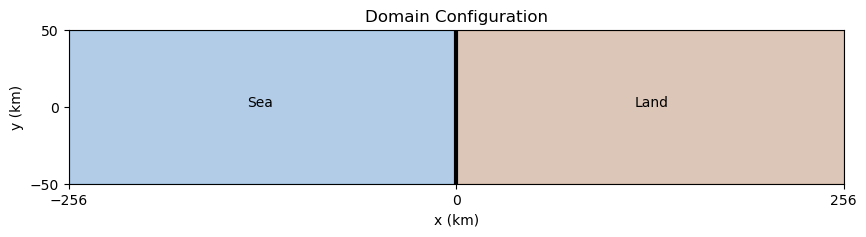

In [2]:
#Domain Configuration
######################################################################################################################################################
channel_aspect_ratio = 5; dpi=300
plt.figure(figsize=(10, 10/channel_aspect_ratio));
plt.axvline(x=0, color='black',linewidth=3);
plt.xlabel('x (km)')
plt.ylabel('y (km)')
plt.title('Domain Configuration')
plt.xlim(-256, 256); plt.xticks(range(-256, 256+1, 256));
plt.ylim(-50, 50); plt.yticks(range(-50, 50+1, 50));

seacolor=(0, 89/255, 179/255)
landcolor=(139/255, 69/255, 19/255) 
plt.text(-256/2-10,0,'Sea'); plt.axvspan(-256, 0, color=seacolor, alpha=0.3) 
plt.text(256/2-10,0,'Land'); plt.axvspan(0, 256, color=landcolor, alpha=0.3) 
plt.savefig(os.path.join(folder_path, f"domain_config.jpg"),dpi=dpi) 

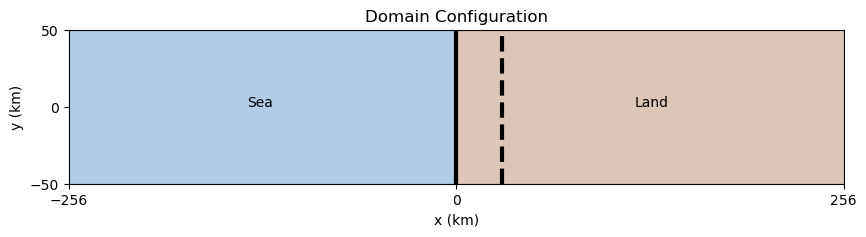

In [14]:
#Limiting Domain
######################################################################################################################################################
channel_aspect_ratio = 5; dpi=300
plt.figure(figsize=(10, 10/channel_aspect_ratio));
plt.axvline(x=0, color='black',linewidth=3);
plt.xlabel('x (km)')
plt.ylabel('y (km)')
plt.title('Domain Configuration')
plt.xlim(-256, 256); plt.xticks(range(-256, 256+1, 256));
plt.ylim(-50, 50); plt.yticks(range(-50, 50+1, 50));

seacolor=(0, 89/255, 179/255)
landcolor=(139/255, 69/255, 19/255) 
plt.text(-256/2-10,0,'Sea'); plt.axvspan(-256, 0, color=seacolor, alpha=0.3) 
plt.text(256/2-10,0,'Land'); plt.axvspan(0, 256, color=landcolor, alpha=0.3) 
plt.savefig(os.path.join(folder_path, f"domain_config.jpg"),dpi=dpi) 


#
plt.axvline(x=30, color='black',linewidth=3,linestyle='dashed');
# plt.axvline(x=0, color='black',linewidth=3,linestyle='dashed');

In [ ]:
#Convergence
######################################################################################################################################################
t=30
zlev=3
whereCLzlev=whereCL['maxconv_x'].isel(time=t,z=zlev).mean()
u=get_3dtime_data(data,'u',t)       
v=get_3dtime_data(data,'v',t) 
dx=np.round((data['xf'][1]-data['xf'][0]),1).item();dy=dx 
[dudx,dudy]=cd2d(u,dx,dy)
[dvdx,dvdy]=cd2d(v,dx,dy)
conv = -(dudx + dvdy)

zlev=3
channel_aspect_ratio = 5
pad=0;dpi=300; figwidth=25
plt.figure(figsize=(figwidth, figwidth/channel_aspect_ratio),dpi=dpi);
contour=plt.contourf(conv[zlev,:,:],levels=np.arange(-1.5,1.5,.01)) #limiting to -1.5 to 1.5 conv
colorbar = plt.colorbar(contour,label=f'{dx*1000:.0f}'+r'$\ s^{-1}$' ,pad=pad)
#####################################################################
[days,hours,mins]=get_time(t)
value=data['zf'][zlev].values; plt.title(f'Convergence at t={t}={days}:{hours}:{mins}, z={value:.2f} km')
#####################################################################
plt.axvline(x=len(data['xf'])/2, color='black',linewidth=3) #plotting coast
plt.axvline(x=data['xf'][-1].astype(int).item()+whereCLzlev.values, color='red',linewidth=3) #plotting CL
plt.legend(('Coastline','Avg Convergence Line'),loc='upper left')
plt.xlabel('x (km)')
plt.ylabel('y (km)')

#####################################################################
plt.xticks(np.arange(0, len(data['yf']), 20));
ticks, _ = plt.yticks()
newticks=ticks-data['yf'][-1].values; newticks=newticks.astype(int)
plt.xticks(ticks=ticks, labels=newticks);

plt.xticks(np.arange(0, len(data['xf']), 50));
ticks, _ = plt.xticks()
newticks=ticks-len(data['xf'])/2; newticks=newticks.astype(int)
plt.xticks(ticks=ticks, labels=newticks);
plt.savefig(os.path.join(folder_path, f"convergence.jpg"),dpi=dpi) 

In [ ]:
##### Along-coast Vertical U
######################################################################################################################################################
t=30; maxlev=3
channel_aspect_ratio = 5
pad=0;dpi=300; figwidth=25
plt.figure(figsize=(figwidth, figwidth/channel_aspect_ratio),dpi=dpi); # plt.subplot(3, 1, 1)
alongcoast=data['u'].isel(time=t,zh=slice(0,np.where(data['zh']<maxlev)[0][-1])).mean(dim='yh')

# bounds = np.linspace(alongcoast.min(), alongcoast.max(), len(uvwind_colors)-1)
# norm = mpl.colors.BoundaryNorm(bounds, uvwind_cmap.N, extend='both')
# plt.contourf(alongcoast,cmap=uvwind_cmap,norm=norm,levels=15)

norm = colors.TwoSlopeNorm(vcenter=0) 
plt.contourf(alongcoast,cmap='bwr',norm=norm,levels=15)
cbar=plt.colorbar(pad=pad); cbar.set_label(r'$m\ s^{-1}$')
plt.grid(True, linestyle=':', color='black')

plt.axvline(x=len(data['xh'])/2, color='black',linewidth=3) #plotting coast
plt.axvline(x=data['xf'][-1].astype(int).item()+whereCL['maxconv_x'].isel(time=t,z=2).mean().values, color='green',linewidth=3) #plotting CL
seacolor=(0, 89/255, 179/255); landcolor=(139/255, 69/255, 19/255) 
plt.axhline(y=0, xmin=0, xmax=0.5, color=seacolor,linewidth=10);
plt.axhline(y=0, xmin=0.5, xmax=1, color=landcolor,linewidth=10);

plt.title('Along-coast Averaged Vertical Plot of Zonal Velocity')
plt.legend(('Coastline','Avg Convergence Line'),loc='upper left')
plt.xlabel('x (km)')
plt.ylabel('z (km)')

#####################################################################
[days,hours,mins]=get_time(t)
plt.text(len(data['xf'])*0.85,7.4,f't={days}:{hours}:{mins}',fontsize=20) 
#####################################################################

#####################################################################
ticks, _ = plt.yticks()
newticks=np.round(data['zh'][ticks.astype(int)].values,1)
plt.yticks(ticks=ticks, labels=newticks);

plt.xticks(np.arange(0, len(data['xh']), 64));
ticks, _ = plt.xticks()
newticks=ticks-len(data['xf'])/2; newticks=newticks.astype(int)
plt.xticks(ticks=ticks, labels=newticks);
plt.savefig(os.path.join(folder_path, f"verticalu.jpg"),dpi=dpi) 

In [ ]:
#Along-coast Vertical Pressure Perturbation
######################################################################################################################################################
t=30; maxlev=3;
channel_aspect_ratio = 5
pad=0;dpi=300; figwidth=25
plt.figure(figsize=(figwidth, figwidth/channel_aspect_ratio),dpi=dpi); # plt.subplot(3, 1, 2)
alongcoast=data['prspert'].isel(time=t,zh=slice(0,np.where(data['zh']<maxlev)[0][-1])).mean(dim='yh')
norm = colors.TwoSlopeNorm(vcenter=0)
plt.contourf(alongcoast,cmap='bwr',norm=norm,levels=15)
cbar=plt.colorbar(pad=pad); cbar.set_label(r'$Pa$')
plt.grid(True, linestyle=':', color='black')

plt.axvline(x=len(data['xf'])/2, color='black',linewidth=3) #plotting coast
plt.axvline(x=data['xf'][-1].astype(int).item()+whereCL['maxconv_x'].isel(time=t,z=2).mean().values, color='green',linewidth=3) #plotting CL
seacolor=(0, 89/255, 179/255); landcolor=(139/255, 69/255, 19/255) 
plt.axhline(y=0, xmin=0, xmax=0.5, color=seacolor,linewidth=10);
plt.axhline(y=0, xmin=0.5, xmax=1, color=landcolor,linewidth=10);

plt.title('Along-coast Averaged Vertical Plot of Presssure Perturbation')
plt.legend(('Coastline','Avg Convergence Line'),loc='upper left')
plt.xlabel('x (km)')
plt.ylabel('z (km)')
#####################################################################
[days,hours,mins]=get_time(t)
plt.text(len(data['xf'])*0.85,7.4,f't={days}:{hours}:{mins}',fontsize=20) 
#####################################################################

#####################################################################
ticks, _ = plt.yticks()
newticks=np.round(data['zh'][ticks.astype(int)].values,1)
plt.yticks(ticks=ticks, labels=newticks);

plt.xticks(np.arange(0, len(data['xh']), 64));
ticks, _ = plt.xticks()
newticks=ticks-len(data['xf'])/2; newticks=newticks.astype(int)
plt.xticks(ticks=ticks, labels=newticks);
plt.savefig(os.path.join(folder_path, f"verticalprspert.jpg"),dpi=dpi)

In [ ]:
# Along-coast Potential Temperature
######################################################################################################################################################
t=30; maxlev=3
channel_aspect_ratio = 5
pad=0;dpi=300; figwidth=25
plt.figure(figsize=(figwidth, figwidth/channel_aspect_ratio),dpi=dpi); # plt.subplot(3, 1, 2)
alongcoast=data['th'].isel(time=t,zh=slice(0,np.where(data['zh']<maxlev)[0][-1])).mean(dim='yh')
plt.contourf(alongcoast,cmap='Reds',levels=15)
cbar=plt.colorbar(pad=pad); cbar.set_label(r'$K$')
plt.grid(True, linestyle=':', color='black')

plt.axvline(x=len(data['xf'])/2, color='black',linewidth=3) #plotting coast
plt.axvline(x=data['xf'][-1].astype(int).item()+whereCL['maxconv_x'].isel(time=t,z=2).mean().values, color='green',linewidth=3) #plotting CL
seacolor=(0, 89/255, 179/255); landcolor=(139/255, 69/255, 19/255) 
plt.axhline(y=0, xmin=0, xmax=0.5, color=seacolor,linewidth=10);
plt.axhline(y=0, xmin=0.5, xmax=1, color=landcolor,linewidth=10);

plt.title('Along-coast Averaged Vertical Plot of Potential Temperature')
plt.legend(('Coastline','Avg Convergence Line'),loc='upper left')
plt.xlabel('x (km)')
plt.ylabel('z (km)')

#####################################################################
[days,hours,mins]=get_time(t)
plt.text(len(data['xf'])*0.8,7.4,f't={days}:{hours}:{mins}',fontsize=20) 
#####################################################################

#####################################################################
ticks, _ = plt.yticks()
newticks=np.round(data['zh'][ticks.astype(int)].values,1)
plt.yticks(ticks=ticks, labels=newticks);

plt.xticks(np.arange(0, len(data['xh']), 64));
ticks, _ = plt.xticks()
newticks=ticks-len(data['xf'])/2; newticks=newticks.astype(int)
plt.xticks(ticks=ticks, labels=newticks);
plt.savefig(os.path.join(folder_path, f"verticaltheta.jpg"),dpi=dpi) 

In [ ]:
##### Along-coast Water Vapor Mixing Ratio
######################################################################################################################################################
t=30; maxlev=3
channel_aspect_ratio = 5
pad=0;dpi=300;figwidth=25
plt.figure(figsize=(figwidth, figwidth/channel_aspect_ratio),dpi=dpi); # plt.subplot(3, 1, 3)
alongcoast=data['qv'].isel(time=t,zh=slice(0,np.where(data['zh']<maxlev)[0][-1])).mean(dim='yh')*1000
plt.contourf(alongcoast,cmap='Blues',levels=15)
cbar=plt.colorbar(pad=pad); cbar.set_label(r'$kg\ kg^{-1}$')
plt.grid(True, linestyle=':', color='black')

plt.axvline(x=len(data['xf'])/2, color='black',linewidth=3) #plotting coast
plt.axvline(x=data['xf'][-1].astype(int).item()+whereCL['maxconv_x'].isel(time=t,z=2).mean().values, color='green',linewidth=3) #plotting CL
seacolor=(0, 89/255, 179/255); landcolor=(139/255, 69/255, 19/255) 
plt.axhline(y=0, xmin=0, xmax=0.5, color=seacolor,linewidth=10);
plt.axhline(y=0, xmin=0.5, xmax=1, color=landcolor,linewidth=10);

plt.title('Along-coast Vertical Plot of Water Vapor Mixing Ratio')
plt.legend(('Coastline','Avg Convergence Line'),loc='upper left')
plt.xlabel('x (km)')
plt.ylabel('z (km)')

#####################################################################
[days,hours,mins]=get_time(t)
plt.text(len(data['xf'])*0.85,7.4,f't={days}:{hours}:{mins}',fontsize=20) 
#####################################################################

#####################################################################
ticks, _ = plt.yticks()
newticks=np.round(data['zh'][ticks.astype(int)].values,1)
plt.yticks(ticks=ticks, labels=newticks);

plt.xticks(np.arange(0, len(data['xh']), 64));
ticks, _ = plt.xticks()
newticks=ticks-len(data['xf'])/2; newticks=newticks.astype(int)
plt.xticks(ticks=ticks, labels=newticks);
plt.savefig(os.path.join(folder_path, f"verticalwatervapor.jpg"),dpi=dpi) 

In [ ]:
# import matplotlib.pyplot as plt
# import matplotlib.animation as animation
# from matplotlib.animation import FuncAnimation
# import os

# channel_aspect_ratio = 5
# dpi=300;figwidth=25
# fig=plt.figure(figsize=(figwidth, figwidth/channel_aspect_ratio),dpi=dpi) # Create figure inside frame function

# def frame(t):
#     print(f'time = {t}')
#     plt.clf()
#     maxlev=3 #225-300
#     pad=0;

    
#     alongcoast=data['qv'].isel(time=t,zh=slice(0,np.where(data['zh']<maxlev)[0][-1])).mean(dim='yh')*1000
#     plt.contourf(alongcoast,cmap='Blues',levels=15)
#     cbar=plt.colorbar(pad=pad); cbar.set_label(r'$kg\ kg^{-1}$')
#     plt.grid(True, linestyle=':', color='black')
    
#     plt.axvline(x=data['xh'][-3].values, color='black',linewidth=3) #plotting coast
#     plt.axvline(x=data['xf'][-1].astype(int).item()+whereCL['maxconv_x'].isel(time=t,z=2).mean().values, color='green',linewidth=3) #plotting CL
#     seacolor=(0, 89/255, 179/255); landcolor=(139/255, 69/255, 19/255) 
#     plt.axhline(y=0, xmin=0, xmax=0.5, color=seacolor,linewidth=10);
#     plt.axhline(y=0, xmin=0.5, xmax=1, color=landcolor,linewidth=10);
    
#     plt.title('Along-coast Vertical Plot of Water Vapor Mixing Ratio')
#     plt.legend(('Coastline','Convergence Line'),loc='upper left')
#     plt.xlabel('x (km)')
#     plt.ylabel('z (km)')
#     #####################################################################
#     [days,hours,mins]=get_time(t)
#     plt.text(len(data['xf'])*0.9,7.4,f't={days}:{hours}:{mins}',fontsize=20) 
#     #####################################################################

    
#     #####################################################################
#     ticks, _ = plt.yticks()
#     newticks=np.round(data['zh'][ticks.astype(int)].values,1)
#     plt.yticks(ticks=ticks, labels=newticks);
    
#     plt.xticks(np.arange(0, len(data['xh']), 64));
#     ticks, _ = plt.xticks()
#     newticks=ticks-data['xf'][-1].values; newticks=newticks.astype(int)
#     plt.xticks(ticks=ticks, labels=newticks);

# start,end=225,301
# animation = FuncAnimation(fig, frame, frames=range(start, end+1), repeat=False)
# animation.save(os.path.join(folder_path, "verticalwatervapor.gif"), writer='Pillow', fps=10)

In [ ]:
#Horizontal Vertical Velocity and Horizontal Zonal Wind
######################################################################################################################################################
t=30; zlev=3; 
channel_aspect_ratio = 5
pad=0;dpi=300
plt.figure(figsize=(25, 50/channel_aspect_ratio),dpi=dpi); plt.subplot(2, 1, 1)
norm = colors.TwoSlopeNorm(vcenter=0)
contour=plt.contourf(data['w'].isel(time=t,zf=zlev),cmap='bwr',norm=norm,levels=15)
plt.colorbar(contour,label=r'$m\ s^{-1}$',pad=pad)

plt.axvline(x=len(data['xf'])/2, color='black',linewidth=3) #plotting coast
plt.axvline(x=data['xf'][-1].astype(int).item()+whereCL['maxconv_x'].isel(time=t,z=2).mean().values, color='green',linewidth=3) 

plt.title('Horizontal Plot of Vertical Velocity')
plt.legend(('Coastline','Avg Convergence Line'),loc='upper left')
plt.xlabel('x (km)')
plt.ylabel('y (km)')
value=data['zf'][zlev].values; 
#####################################################################
[days,hours,mins]=get_time(t)
plt.text(len(data['xf'])*0.85,len(data['yf'])*0.75,f't={days}:{hours}:{mins}',fontsize=20) 
plt.text(len(data['xf'])*0.85,len(data['yf'])*0.85,f'z={value:.3f} m',fontsize=20) 
#####################################################################


#####################################################################
plt.yticks(np.arange(0, len(data['yh'])+1, 20));
ticks, _ = plt.yticks()
newticks=ticks-np.floor(len(data['yf'])/2); newticks=newticks.astype(int)
plt.yticks(ticks=ticks, labels=newticks);

plt.xticks(np.arange(0, len(data['xh']), 64));
ticks, _ = plt.xticks()
newticks=ticks-len(data['xf'])/2; newticks=newticks.astype(int)
plt.xticks(ticks=ticks, labels=newticks);

########################################################################
########################################################################
zlev=3
# channel_aspect_ratio = 5; #plt.figure(figsize=(25, 50/channel_aspect_ratio),dpi=dpi); #don't use for subplot
plt.subplot(2, 1, 2)
norm = colors.TwoSlopeNorm(vcenter=0)
contour=plt.contourf(data['u'].isel(time=t,zh=zlev),cmap='bwr',norm=norm,levels=15)
plt.colorbar(contour,label=r'$m\ s^{-1}$', pad=pad)

plt.axvline(x=len(data['xf'])/2, color='black',linewidth=3) #plotting coast
plt.axvline(x=data['xf'][-1].astype(int).item()+whereCL['maxconv_x'].isel(time=t,z=2).mean().values, color='green',linewidth=3) 

plt.title('Horizontal Plot of Zonal Wind')
plt.legend(('Coastline','Avg Convergence Line'),loc='upper left')
plt.xlabel('x (km)')
plt.ylabel('y (km)')

#####################################################################
plt.yticks(np.arange(0, len(data['yh'])+1, 20));
ticks, _ = plt.yticks()
newticks=ticks-np.floor(len(data['yf'])/2); newticks=newticks.astype(int)
plt.yticks(ticks=ticks, labels=newticks);

plt.xticks(np.arange(0, len(data['xh']), 64));
ticks, _ = plt.xticks()
newticks=ticks-len(data['xf'])/2; newticks=newticks.astype(int)
plt.xticks(ticks=ticks, labels=newticks);

plt.savefig(os.path.join(folder_path, f"horizontalw-u.jpg"),dpi=dpi) 

In [ ]:
# # #Comparing Vertical Velocity and Moisture around CL for single timesteps

# # find left and right of CL axis 
# import math
# kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1) #finds how many x grids is 1 km
# def mirror(lst):
#     lst_mirror=lst[::-1]
#     return lst_mirror
# def make_xy(n):
#     dx=data['xh'].values[1]-data['xh'][0].values;dy=dx
#     #x
#     lst0=[-n]*n
#     lst1=list(np.arange(-(2*n-1)/2,((2*n-1)/2)+1,1))
#     lst2=[n]*(2*n)
#     lst3=[-n]*n
#     x=lst0+lst1+lst2+mirror(lst1)+lst3
#     x=np.array([ind*dx for ind in x])
#     #y
#     y=[]
#     arr1 = list(np.arange(2*n, (8*n)))
#     arr2 = list(np.arange(0, (2*n-1)+1))
#     rearange = arr1+arr2
#     y=[x[ind] for ind in rearange]
#     y=np.array([ind*dy for ind in y])
#     return x, y
# def make_inds_xy(n):
#     #inds_x
#     lst0=[-n]*n
#     lst1=list(np.arange(-n+1,(n-1)+1,1))
#     lst2=[n]*(2*n+1)
#     lst3=[-n]*(n+1)
#     inds_x=lst0+lst1+lst2+mirror(lst1)+lst3
#     inds_x=np.array(inds_x)
#     #inds_y
#     arr1 = list(np.arange(2*n, (8*n)))
#     arr2 = list(np.arange(0, (2*n-1)+1))
#     rearange = arr1+arr2
#     inds_y=np.array([inds_x[ind] for ind in rearange])
#     return inds_x, inds_y

# def leftright(u,v): #TESTING
#     #(0) getting wind angle
#     theta=math.atan2(v,u) #returns wind angle between -180 and 180
#     # print(f'theta is {math.degrees(theta)} deg')
    
#     ns=2*kms #2 kms around CL
#     #(1) starting for loop
#     xs,ys=[],[]
#     dx=data['xh'].values[1]-data['xh'][0].values;dy=dx
#     for n in range(1,(ns)+1):
#         #(2) make x and y
#         [x,y]=make_xy(n)
#         #(3) make indx and indy
#         [inds_x,inds_y]=make_inds_xy(n)
#         #(4) find tau
#         tau = np.arctan2(y, x)
#         #(5) use search sorted to find which range theta falls in 
#         ind=(8*n-2)-(np.searchsorted(mirror(tau),theta)-1)
#         #(6) get x and y inds
#         if np.degrees(theta) in [-180,180]: #needed since atan2 function discontinuity
#             xs.append(-n);ys.append(0)
#         else:
#             xs.append(inds_x[ind]);ys.append(inds_y[ind]) 
#         # print([inds_x[ind],inds_y[ind]])
#     xs=[-ind for ind in mirror(xs)]+[0]+xs
#     ys=[-ind for ind in mirror(ys)]+[0]+ys
#     # print(xs,ys)
#     return xs,ys
# ############################################################################################################
# def lrdata(t,var):
#     zlev=3
#     n=2*kms
#     result=np.zeros((2*n+1))
#     for ylev in range(len(data['yh'])):
#         print(f'y level: {ylev}')
#         CL=whereCL['maxconv_x'].isel(time=t,y=ylev,z=zlev).values
#         xlev=np.where(CL!=-1)[0]
#         for xlev in xlev:
#             u=data['u'].isel(time=t,yh=ylev,zh=zlev,xf=xlev).values
#             v=data['v'].isel(time=t,yf=ylev ,zh=zlev,xh=xlev).values
#             [xs,ys]=leftright(u,v);  
            
#             xrange=[ind+xlev for ind in xs]
#             yrange=[np.mod(ind+ylev,len(data['yh'])) for ind in ys]
    
#             n=2*kms
#             lr = np.zeros(2*n+1)
#             for ind in range(len(xrange)):
#                 if var=='w':
#                     data_point = data['w'].isel(time=t, zf=zlev, xh=xrange[ind], yh=yrange[ind]).values
#                 elif var=='qv':
#                     data_point = data['qv'].isel(time=t, zh=zlev, xh=xrange[ind], yh=yrange[ind]).values
#                 elif var=='qvconv':
#                     ##########################################################################################
#                     def get_3dtime_data(data,varname,t,zlev):
#                         try:
#                             cloud_var=data[varname].isel(time=t,zh=zlev).values
#                         except Exception as e:
#                             cloud_var=data[varname].isel(time=t,zf=zlev).values
#                         return cloud_var
#                     def cd2d_zlev(f,dx,dy): #size not compatible, cant calculate adjacent gradient
#                         ddx = (
#                                 f[:, 1:  ]
#                                 -
#                                 f[:, 0:-1]
#                             ) / (
#                             2 * dx
#                         )
                    
#                         ddy = (
#                             f[1:, :]
#                             -
#                             f[0:-1, :]
#                         ) / (
#                             2 * dy
#                         )
                    
#                         return ddx, ddy
                    
#                     #getting moisture convergence 
#                     dx=data['xf'][1]-data['xf'][0];dx=dx.item();dy=dx
#                     u=get_3dtime_data(data,'u',t,zlev)       
#                     v=get_3dtime_data(data,'v',t,zlev)  
    
#                     [dudx,dudy]=cd2d_zlev(u,dx,dy)
#                     [dvdx,dvdy]=cd2d_zlev(v,dx,dy)
#                     conv = -(dudx + dvdy)
                    
                    
#                     qv=get_3dtime_data(data,'qv',t,zlev)  
#                     data_point = qv*conv
#                     data_point=data_point[yrange[ind],xrange[ind]]
#                 lr[ind]=data_point
#                 ##########################################################################################
#             result=np.vstack((result,lr))
#     result=result[1:]
#     return result


# t=30
# result1=lrdata(t,'w')
# result2=lrdata(t,'qv')
# result3=lrdata(t,'qvconv')
# ds1= xr.Dataset({'resultw': (['x', 'y'], result1),
#                  'resultqv': (['x', 'y'], result2),
#                  'resultqvconv': (['x', 'y'], result3)})
# ds1.to_netcdf('leftright_savesingle.nc') 

In [ ]:
# # #Comparing Vertical Velocity and Moisture around CL for all timesteps TESTING
# zlev=3#
# whereCLmean=np.round(whereCL['maxconv_x'].isel(z=zlev).mean(dim='time'),0).astype(int)#
# datameanu=data['u'].isel(zh=zlev).mean(dim='time')#
# datameanv=data['v'].isel(zh=zlev).mean(dim='time')#
# datameanw=data['w'].isel(zf=zlev).mean(dim='time')#
# datameanqv=data['qv'].isel(zh=zlev).mean(dim='time')#
# # find left and right of CL axis 
# import math
# kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1) #finds how many x grids is 1 km
# def mirror(lst):
#     lst_mirror=lst[::-1]
#     return lst_mirror
# def make_xy(n):
#     dx=data['xh'].values[1]-data['xh'][0].values;dy=dx
#     #x
#     lst0=[-n]*n
#     lst1=list(np.arange(-(2*n-1)/2,((2*n-1)/2)+1,1))
#     lst2=[n]*(2*n)
#     lst3=[-n]*n
#     x=lst0+lst1+lst2+mirror(lst1)+lst3
#     x=np.array([ind*dx for ind in x])
#     #y
#     y=[]
#     arr1 = list(np.arange(2*n, (8*n)))
#     arr2 = list(np.arange(0, (2*n-1)+1))
#     rearange = arr1+arr2
#     y=[x[ind] for ind in rearange]
#     y=np.array([ind*dy for ind in y])
#     return x, y
# def make_inds_xy(n):
#     #inds_x
#     lst0=[-n]*n
#     lst1=list(np.arange(-n+1,(n-1)+1,1))
#     lst2=[n]*(2*n+1)
#     lst3=[-n]*(n+1)
#     inds_x=lst0+lst1+lst2+mirror(lst1)+lst3
#     inds_x=np.array(inds_x)
#     #inds_y
#     arr1 = list(np.arange(2*n, (8*n)))
#     arr2 = list(np.arange(0, (2*n-1)+1))
#     rearange = arr1+arr2
#     inds_y=np.array([inds_x[ind] for ind in rearange])
#     return inds_x, inds_y

# def leftright(u,v): #TESTING
#     #(0) getting wind angle
#     theta=math.atan2(v,u) #returns wind angle between -180 and 180
#     # print(f'theta is {math.degrees(theta)} deg')
    
#     ns=2*kms #2 kms around CL
#     #(1) starting for loop
#     xs,ys=[],[]
#     dx=data['xh'].values[1]-data['xh'][0].values;dy=dx
#     for n in range(1,(ns)+1):
#         #(2) make x and y
#         [x,y]=make_xy(n)
#         #(3) make indx and indy
#         [inds_x,inds_y]=make_inds_xy(n)
#         #(4) find tau
#         tau = np.arctan2(y, x)
#         #(5) use search sorted to find which range theta falls in 
#         ind=(8*n-2)-(np.searchsorted(mirror(tau),theta)-1)
#         #(6) get x and y inds
#         if np.degrees(theta) in [-180,180]: #needed since atan2 function discontinuity
#             xs.append(-n);ys.append(0)
#         else:
#             xs.append(inds_x[ind]);ys.append(inds_y[ind]) 
#         # print([inds_x[ind],inds_y[ind]])
#     xs=[-ind for ind in mirror(xs)]+[0]+xs
#     ys=[-ind for ind in mirror(ys)]+[0]+ys
#     # print(xs,ys)
#     return xs,ys
# ############################################################################################################
# def lrdata(t,var):
#     t=t#
#     zlev=3
#     n=2*kms
#     result=np.zeros((2*n+1))
#     for ylev in range(len(data['yh'])):
#         print(f'y level: {ylev}')
#         CL=whereCLmean.isel(y=ylev).values
#         xlev=np.where(CL!=-1)[0]
#         for xlev in xlev:
#             u=datameanu.isel(yh=ylev,xf=xlev).values
#             v=datameanv.isel(yf=ylev ,xh=xlev).values
#             [xs,ys]=leftright(u,v);  
            
#             xrange=[ind+xlev for ind in xs]
#             yrange=[np.mod(ind+ylev,len(data['yh'])) for ind in ys]
    
#             n=2*kms
#             lr = np.zeros(2*n+1)
#             for ind in range(len(xrange)):
#                 if var=='w':
#                     data_point = datameanw.isel(xh=xrange[ind], yh=yrange[ind]).values
#                 elif var=='qv':
#                     data_point = datameanqv.isel(xh=xrange[ind], yh=yrange[ind]).values
#                 elif var=='qvconv':
#                     ##########################################################################################
#                     def get_3dtime_data(data,varname,t,zlev):
#                         t=t#
#                         zlev=zlev#
#                         varname=varname#
#                         try:
#                             cloud_var=data.values
#                         except Exception as e:
#                             cloud_var=data.values
#                         return cloud_var
#                     def cd2d_zlev(f,dx,dy): #size not compatible, cant calculate adjacent gradient
#                         ddx = (
#                                 f[:, 1:  ]
#                                 -
#                                 f[:, 0:-1]
#                             ) / (
#                             2 * dx
#                         )
                    
#                         ddy = (
#                             f[1:, :]
#                             -
#                             f[0:-1, :]
#                         ) / (
#                             2 * dy
#                         )
                    
#                         return ddx, ddy
                    
#                     #getting moisture convergence 
#                     dx=data['xf'][1]-data['xf'][0];dx=dx.item();dy=dx
#                     # u=get_3dtime_data(datamean,'u',t,zlev)  #    
#                     # v=get_3dtime_data(datamean,'v',t,zlev)  #
#                     u=datameanu.values
#                     v=datameanv.values
    
#                     [dudx,dudy]=cd2d_zlev(u,dx,dy)
#                     [dvdx,dvdy]=cd2d_zlev(v,dx,dy)
#                     conv = -(dudx + dvdy)
                    
                    
#                     # qv=get_3dtime_data(datamean,'qv',t,zlev)#
#                     qv=datameanqv
#                     data_point = qv*conv
#                     data_point=data_point[yrange[ind],xrange[ind]]
#                 lr[ind]=data_point
#                 ##########################################################################################
#             result=np.vstack((result,lr))
#     result=result[1:]
#     return result


# t=30#
# result1=lrdata(t,'w')
# result2=lrdata(t,'qv')
# result3=lrdata(t,'qvconv')
# ds1= xr.Dataset({'resultw': (['x', 'y'], result1),
#                  'resultqv': (['x', 'y'], result2),
#                  'resultqvconv': (['x', 'y'], result3)})
# ds1.to_netcdf('leftright_savemean.nc') 

In [ ]:
# #Contour Plots
# results=xr.open_dataset('leftright_save_single.nc')
# resultw=results['resultw']
# resultqv=results['resultqv']
# resultqvconv=results['resultqvconv']
# #zooming in plot
# #sectioned mean
# resultw=resultw.coarsen(x=100,boundary="pad").mean()
# resultqv=resultqv.coarsen(x=100,boundary="pad").mean()
# resultqvconv=resultqvconv.coarsen(x=100,boundary="pad").mean()
# # #running mean
# # resultw=resultw.rolling(x=100, center=True, min_periods=1).mean()
# # resultqv=resultqv.rolling(x=100, center=True, min_periods=1).mean()
# # resultqvconv=resultqvconv.rolling(x=100, center=True, min_periods=1).mean()

# kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1) #finds how many x grids is 1 km
# def lrplot(result,cmap,label,var,vartitle):
#     zlev=3
#     if var in ['w','qvconv']:
#         norm = colors.TwoSlopeNorm(vcenter=0)
#         contour=plt.contourf(result,cmap=cmap,norm=norm,levels=10)
#     else:
#         contour=plt.contourf(result,cmap=cmap,levels=10)
    
#     colorbar=plt.colorbar(contour, pad=pad)
#     colorbar.set_label(label=label, fontsize=8)
#     ####################################################
#     plt.xticks(range(len(result[0]))); 
#     ticks, _ = plt.xticks()
#     newticks=(ticks-2*kms); newticks=newticks.astype(int)
#     plt.xticks(ticks=ticks, labels=newticks);
    
#     ticks, _ = plt.yticks()
#     newticks=ticks-np.floor(len(result)/2); newticks=newticks.astype(int)
#     plt.yticks(ticks=ticks, labels=newticks);
#     ####################################################
#     plt.axvline(x=2*kms, color='green',label='CL',linewidth=2) #plotting coast
#     ####################################################
#     plt.title(f'Horizontal Plot of {vartitle} around CL')
#     # plt.legend(loc='upper left',fontsize=6)
#     plt.xlabel('x (km)')
#     plt.ylabel('y (km)')
#     value=data['zf'][zlev].values; 
#     plt.text(2*kms*1.6,len(result)*0.85,f'z={value:.2f} m',fontsize=8) 
#     ####################################################

# pad=0;dpi=600;width=5
# channel_aspect_ratio = 1
# plt.figure(figsize=(width, width/channel_aspect_ratio),dpi=dpi);
# plt.subplot(3, 1, 1);plt.subplots_adjust(hspace=0.5)
# lrplot(resultw,'bwr',r'$m\ s^{-1}$','w','W')
# plt.subplot(3, 1, 2);
# lrplot(resultqv,'Blues',r'$kg kg^{-1}$','qv','QV')
# plt.subplot(3, 1, 3);
# lrplot(resultqvconv,'bwr',r'$kg\ kg^{-1}\ s^{-1}$','qvconv','QV Conv')
# plt.tight_layout()

# plt.savefig(os.path.join(folder_path, f"CLleftrightcontour.jpg"),dpi=dpi) 

In [ ]:
# #Scatter Plots
# n=2*kms
# lrange=np.arange(0,(n))
# mrange=np.arange(n,(n)+1,1)
# rrange=np.arange(n+1,(2*n)+1)

# pad=0;dpi=300;width=10
# channel_aspect_ratio=5
# plt.figure(figsize=(width, 20/channel_aspect_ratio),dpi=dpi);

# lresultw=resultw[:,lrange].mean(dim='y');mresultw=resultw[:,mrange].mean(dim='y');rresultw=resultw[:,rrange].mean(dim='y')
# plt.subplot(2, 2, 1); #plt.subplots_adjust(hspace=0.5)
# plt.scatter(np.arange(len(lresultw)),lresultw,label="w CL-2km",color='blue',s=20); 
# plt.scatter(np.arange(len(mresultw)),mresultw,label="w CL",color='green',s=20);
# plt.scatter(np.arange(len(rresultw)),rresultw,label="w CL+2km",color='orange',s=20);
# plt.axhline(np.mean(lresultw),color='blue')
# plt.axhline(np.mean(mresultw),color='green')
# plt.axhline(np.mean(rresultw),color='orange')
# plt.xlabel('time in 5 minute increments')
# plt.ylabel(r'$m\ s^{-1}$')
# plt.legend(loc='upper left',fontsize=10)
# plt.title('comparing mean W +-2km of CL location at each time')

# lresultqv=resultqv[:,lrange].mean(dim='y');mresultqv=resultqv[:,mrange].mean(dim='y');rresultqv=resultqv[:,rrange].mean(dim='y')
# plt.subplot(2,2,2)
# plt.scatter(np.arange(len(lresultqv)),lresultqv,label="qv CL-2km",color='blue',s=20); 
# plt.scatter(np.arange(len(mresultqv)),mresultqv,label="qv CL",color='green',s=20); 
# plt.scatter(np.arange(len(rresultqv)),rresultqv,label="qv CL+2km",color='orange',s=20); 
# plt.axhline(np.mean(lresultqv),color='blue')
# plt.axhline(np.mean(mresultqv),color='green')
# plt.axhline(np.mean(rresultqv),color='orange')
# plt.xlabel('time in 5 minute increments')
# plt.ylabel(r'$kg\ kg^{-1}$')
# plt.legend(loc='upper left',fontsize=10)

# lresultqvconv=resultqvconv[:,lrange].mean(dim='y');mresultqvconv=resultqvconv[:,mrange].mean(dim='y');rresultqvconv=resultqvconv[:,rrange].mean(dim='y')
# plt.subplot(2,2,3)
# plt.scatter(np.arange(len(lresultqvconv)),lresultqvconv,label="qv conv CL-2km",color='blue',s=20); 
# plt.scatter(np.arange(len(mresultqvconv)),mresultqvconv,label="qv conv CL",color='green',s=20); 
# plt.scatter(np.arange(len(rresultqvconv)),rresultqvconv,label="qv conv CL+2km",color='orange',s=20); 
# plt.axhline(np.mean(lresultqvconv),color='blue')
# plt.axhline(np.mean(mresultqvconv),color='green')
# plt.axhline(np.mean(rresultqvconv),color='orange')
# plt.xlabel('time in 5 minute increments')
# plt.ylabel(r'$kg\ kg^{-1}\ s^{-1}$')
# plt.legend(loc='upper left',fontsize=10)

# plt.tight_layout()
# plt.savefig(os.path.join(folder_path, f"CLleftrightscatter.jpg"),dpi=dpi) 

In [9]:
## Converts all figures to PDF
######################################################################################################################################################
from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from PIL import Image
import os

def jpg_to_pdf(input_folder, output_pdf):
    # Get a list of all JPG files in the input folder
    jpg_files = [file for file in os.listdir(input_folder) if file.endswith('.jpg')]
    jpg_files = ['domain_config.jpg','convergence.jpg','verticalu.jpg',
                 'verticaltheta.jpg','verticalprspert.jpg','verticaltheta.jpg',
                 'verticalwatervapor.jpg','horizontalw-u.jpg','CLleftrightcontour.jpg',
                 'CLleftrightscatter.jpg'] #***
    
    # Create a PDF canvas
    c = canvas.Canvas(output_pdf, pagesize=letter)

    # Loop through each JPG file and add it to the PDF
    for jpg_file in jpg_files:
        # Open the JPG image using PIL
        img = Image.open(os.path.join(input_folder, jpg_file))

        # Calculate the aspect ratio to maintain image proportions
        width, height = img.size
        aspect_ratio = width / height

        # Add the image to the PDF
        c.setPageSize((width, height))
        c.drawInlineImage(os.path.join(input_folder, jpg_file), 0, 0, width=width, height=height)

        # Add a new page for the next image
        c.showPage()

    # Save the PDF
    c.save()

# Example usage:
input_folder = '/mnt/lustre/koa/koastore/torri_group/air_directory/figures/062217' 
output_pdf = '/mnt/lustre/koa/koastore/torri_group/air_directory/figures/062217/figures_062217.pdf'
jpg_to_pdf(input_folder, output_pdf)

In [ ]:
# # find left and right of CL axis TESTING 
# import math
# kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1) #finds how many x grids is 1 km
# kms=5
# # kms=1
# def mirror(lst):
#     lst_mirror=lst[::-1]
#     return lst_mirror
# def make_xy(n):
#     dx=data['xh'].values[1]-data['xh'][0].values;dy=dx
#     #x
#     lst0=[-n]*n
#     lst1=list(np.arange(-(2*n-1)/2,((2*n-1)/2)+1,1))
#     lst2=[n]*(2*n)
#     lst3=[-n]*n
#     x=lst0+lst1+lst2+mirror(lst1)+lst3
#     x=np.array([ind*dx for ind in x])
#     #y
#     y=[]
#     arr1 = list(np.arange(2*n, (8*n)))
#     arr2 = list(np.arange(0, (2*n-1)+1))
#     rearange = arr1+arr2
#     y=[x[ind] for ind in rearange]
#     y=np.array([ind*dy for ind in y])
#     return x, y
# def make_inds_xy(n):
#     #inds_x
#     lst0=[-n]*n
#     lst1=list(np.arange(-n+1,(n-1)+1,1))
#     lst2=[n]*(2*n+1)
#     lst3=[-n]*(n+1)
#     inds_x=lst0+lst1+lst2+mirror(lst1)+lst3
#     inds_x=np.array(inds_x)
#     #inds_y
#     arr1 = list(np.arange(2*n, (8*n)))
#     arr2 = list(np.arange(0, (2*n-1)+1))
#     rearange = arr1+arr2
#     inds_y=np.array([inds_x[ind] for ind in rearange])
#     return inds_x, inds_y

# def leftright(degrees): #TESTING
#     #(0) getting wind angle
#     # theta=math.atan2(v,u) #returns wind angle between -180 and 180
#     theta=np.radians(degrees)
#     # print(f'theta is {math.degrees(theta)} deg')
    
#     ns=2*kms #2 kms around CL
#     #(1) starting for loop
#     xs,ys=[],[]
#     dx=data['xh'].values[1]-data['xh'][0].values;dy=dx
#     for n in range(1,(ns)+1):
#         #(2) make x and y
#         [x,y]=make_xy(n)
#         #(3) make indx and indy
#         [inds_x,inds_y]=make_inds_xy(n)
#         #(4) find tau
#         tau = np.arctan2(y, x)
#         #(5) use search sorted to find which range theta falls in 
#         ind=(8*n-2)-(np.searchsorted(mirror(tau),theta)-1)
#         #(6) get x and y inds
#         if np.degrees(theta) in [-180,180]: #needed since atan2 function discontinuity
#             xs.append(-n);ys.append(0)
#         else:
#             xs.append(inds_x[ind]);ys.append(inds_y[ind]) 
#         # print([inds_x[ind],inds_y[ind]])
#     # xs=[-ind for ind in mirror(xs)]+[0]+xs
#     # ys=[-ind for ind in mirror(ys)]+[0]+ys
#     # print(xs,ys)
#     return xs,ys

# import matplotlib.patches as patches
# def plot_5x5_grid(angle_deg,xs,ys,fig,ax):
#     ns=2*kms
#     #make grid
#     angle_rad = np.radians(angle_deg)
#     # fig, ax = plt.subplots() #used in update
#     for i in range(1, 2*ns+1):
#         ax.plot([i, i], [0, 2*ns+1], 'k-')
#         ax.plot([0, 2*ns+1], [i, i], 'k-')

#     ax.set_xlim(0, 2*ns+1)
#     ax.set_ylim(0, 2*ns+1)
#     ax.set_xticks(range(2*ns+2))
#     ax.set_yticks(range(2*ns+2))
#     ax.tick_params(axis='both', which='both', length=0)
#     ax.tick_params(axis='both', which='both', length=0)
#     ax.set_xticklabels([])
#     ax.set_yticklabels([])

#     #vector
#     dx = ns * np.cos(angle_rad)
#     dy = ns * np.sin(angle_rad)
#     ax.quiver(ns+0.5, ns+0.5, dx, dy, angles='xy', scale_units='xy', scale=1, color='r',zorder=2,label=f'{angle_deg:.0f} °')

#     #fill
#     #center
#     rect=patches.Rectangle((0+ns, 0+ns), 1, 1, linewidth=1, edgecolor='none', facecolor='black',label='center')
#     ax.add_patch(rect)
#     #rightside
#     for ind in range(len(xs)):
#         rect=patches.Rectangle((xs[ind]+ns, ys[ind]+ns), 1, 1, linewidth=1, edgecolor='none', facecolor='orange')
#         ax.add_patch(rect)
#         if ind == 0:
#             rect.set_label('CL right')
#     #leftside
#     xs2=[-ind for ind in xs];ys2=[-ind for ind in ys]
#     for ind in range(len(xs2)):
#         rect=patches.Rectangle((xs2[ind]+ns, ys2[ind]+ns), 1, 1, linewidth=1, edgecolor='none', facecolor='blue')
#         ax.add_patch(rect)
#         if ind == 0:
#             rect.set_label('CL left')
#     ax.legend(loc='center')
    
# # #Plotting
# # amount=36; 
# # fig, ax = plt.subplots()
# # for theta in np.concatenate((np.arange(0, 181, amount), np.arange(-180 + amount, 0, amount))):
# #     [xs,ys]=leftright(theta)
# #     plot_5x5_grid(theta,xs,ys,fig,ax)
    
# # for theta in np.arange(-180+amount,0,amount):
# #     [xs,ys]=leftright(theta)
# #     plot_5x5_grid(theta,xs,ys,fig,ax)

# #Animation
# from matplotlib.animation import FuncAnimation
# amount=1
# angles=np.concatenate((np.arange(0, 181, amount), np.arange(-180 + amount, 0, amount)))

# fig, ax = plt.subplots()
# def update(theta):
#     ax.clear()
#     xs, ys = leftright(theta)
#     plot_5x5_grid(theta, xs, ys,fig,ax)

# ani = FuncAnimation(fig, update, frames=angles, repeat=False)
# ani.save('grid_animation.gif', writer='pillow', fps=10)

In [ ]:
# import matplotlib.colors as mcolors
# uvwind_colors = [
# (255, 255, 255),  
# (90,211,255),
# (0,155,231), 
# (0,102,251),  
# (0,153,0),
# (57,255,0),
# (250,255,0), 
# (248,205,13),  
# (255,153,0),
# (255,0,0),
# (205,0,0),  
# (169,0,154),
# (255,0,255),
# (200,162,212),
# (112,73,142)]
# uvwind_colors = [(r / 255, g / 255, b / 255) for r, g, b in uvwind_colors]
# uvwind_cmap = mcolors.ListedColormap(uvwind_colors)
# uvwind_cmap

# # bounds = np.linspace(alongcoast.min(), alongcoast.max(), len(uvwind_colors)-1)
# # left = np.linspace(alongcoast.min(), 0, int((len(uvwind_colors)-1)/2))
# # right = np.linspace(0, alongcoast.max(), int((len(uvwind_colors)-1)/2))
# # bounds=np.concatenate((left,right[1:]))
# # norm = mpl.colors.BoundaryNorm(bounds, uvwind_cmap.N, extend='both')
# # plt.contourf(alongcoast,cmap=uvwind_cmap,norm=norm,levels=15)